# 📊 Sandbox Visual — Campos del Pipeline de Estadísticas
Visualización estática campo a campo. Datos reales del endpoint de la API.

---

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

# Ruta al proyecto
if os.path.abspath('../..') not in sys.path:
    sys.path.insert(0, os.path.abspath('../..'))

## Campo 1 — Origen del Proceso
`GET /stats/origen`

In [2]:
# JSON real del endpoint /stats/origen
data = {
    "metrica": "Origen del Proceso",
    "frecuencia": {
        "LinkedIn": 120,
        "GetOnBoard": 58,
        "CompuTrabajo": 31
    },
    "distribucion_porcentaje": {
        "LinkedIn": 57.42,
        "GetOnBoard": 27.75,
        "CompuTrabajo": 14.83
    },
    "moda": "LinkedIn",
    "ratio_nulos": "0.00%"
}

In [3]:
# --- Tarjetas KPI: moda + integridad ---
display(Markdown(
    f"""
| 🏆 Portal dominante | ✅ Integridad del campo |
|---|---|
| **{data['moda']}** | **{data['ratio_nulos']} nulos** |
"""
))


| 🏆 Portal dominante | ✅ Integridad del campo |
|---|---|
| **LinkedIn** | **0.00% nulos** |


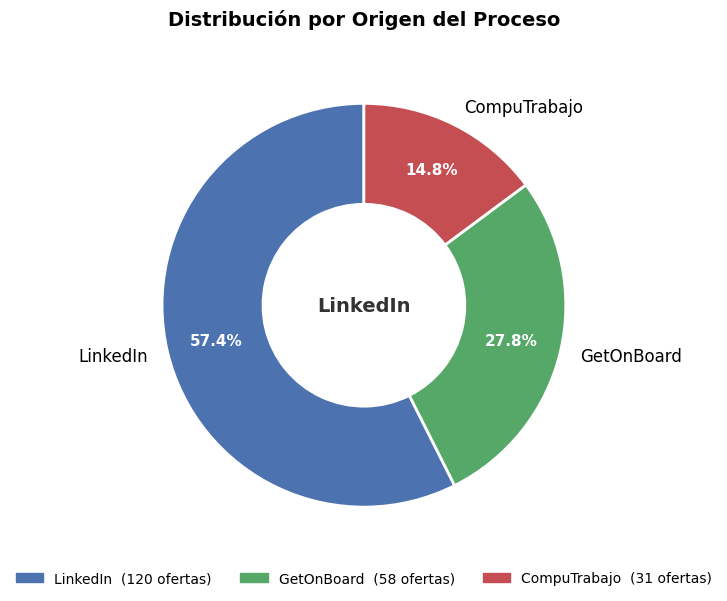

In [4]:
# --- Donut Chart: distribución porcentual ---
labels = list(data['distribucion_porcentaje'].keys())
sizes  = list(data['distribucion_porcentaje'].values())
freqs  = list(data['frecuencia'].values())

colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.5, 'linewidth': 2, 'edgecolor': 'white'},
    pctdistance=0.75
)

# Estilo de textos
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Centro del donut: portal dominante
ax.text(0, 0, data['moda'], ha='center', va='center',
        fontsize=14, fontweight='bold', color='#333333')

# Leyenda con frecuencias reales
legend_labels = [f"{l}  ({f} ofertas)" for l, f in zip(labels, freqs)]
patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          ncol=3, fontsize=10, frameon=False)

ax.set_title('Distribución por Origen del Proceso', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()